# Plain implementation of YOLOv12 trained on our custom dataset (RGB)
Created following this tutorial https://blog.roboflow.com/train-yolov12-model/

### Installing required packages

In [3]:
!git clone https://github.com/sunsmarterjie/yolov12
%cd yolov12
%pip install roboflow supervision flash-attn --upgrade -q
%pip install -r requirements.txt
%pip install -e .
%pip install --upgrade flash-attn

# Not in tutorial but necesarry:
%pip install huggingface_hub ultralytics

Cloning into 'yolov12'...
remote: Enumerating objects: 968, done.
remote: Counting objects: 100% (246/246), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 968 (delta 219), reused 199 (delta 189), pack-reused 722 (from 1)
Receiving objects: 100% (968/968), 1.60 MiB | 6.64 MiB/s, done.
Resolving deltas: 100% (460/460), done.
/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/yolov12
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.idi.ntnu.no
ERROR: flash_attn-2.7.3+cu11torch2.2cxx11abiFALSE-cp311-cp311-linux_x86_64.whl is not a supported wheel on this platform.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.idi.ntnu.no
Obtaining file:///home/omtalmo/Olaf_TTK4

### Loading dataset
The data is structured like this: I have one folder called "rgb". Inside the folder is a data.yaml file, a folder called "images" and a folder called "labels". The folder "images" contains the subfolders "test", "train" and "valid", which all contain png files. The folder "labels" contain the subfolders "train" and "valid", which both contain txt files. 

In [8]:
dataset_path = "/home/omtalmo/Olaf_TTK4265/Poles/rgb"

In [ ]:
from ultralytics import YOLO

# Initialize YOLOv12 model (s = small version)
model = YOLO('yolov12s.yaml')  

# Train the model using RGB data
results = model.train(
    data=f'{dataset_path}/data.yaml',
    epochs=250
)

Processing 46 test images...


SupervisionWarnings: BoundingBoxAnnotator is deprecated: `BoundingBoxAnnotator` is deprecated and has been renamed to `BoxAnnotator`. `BoundingBoxAnnotator` will be removed in supervision-0.26.0.


  0%|          | 0/46 [00:00<?, ?it/s]


0: 416x640 2 poles, 5.1ms
Speed: 1.0ms preprocess, 5.1ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 (no detections), 5.8ms
Speed: 1.1ms preprocess, 5.8ms inference, 0.2ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 5.5ms
Speed: 1.1ms preprocess, 5.5ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 5.5ms
Speed: 1.0ms preprocess, 5.5ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 5.4ms
Speed: 1.1ms preprocess, 5.4ms inference, 0.5ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 1 pole, 8.7ms
Speed: 1.5ms preprocess, 8.7ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 3 poles, 5.7ms
Speed: 1.1ms preprocess, 5.7ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 2 poles, 5.6ms
Speed: 1.1ms preprocess, 5.6ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)

0: 416x640 

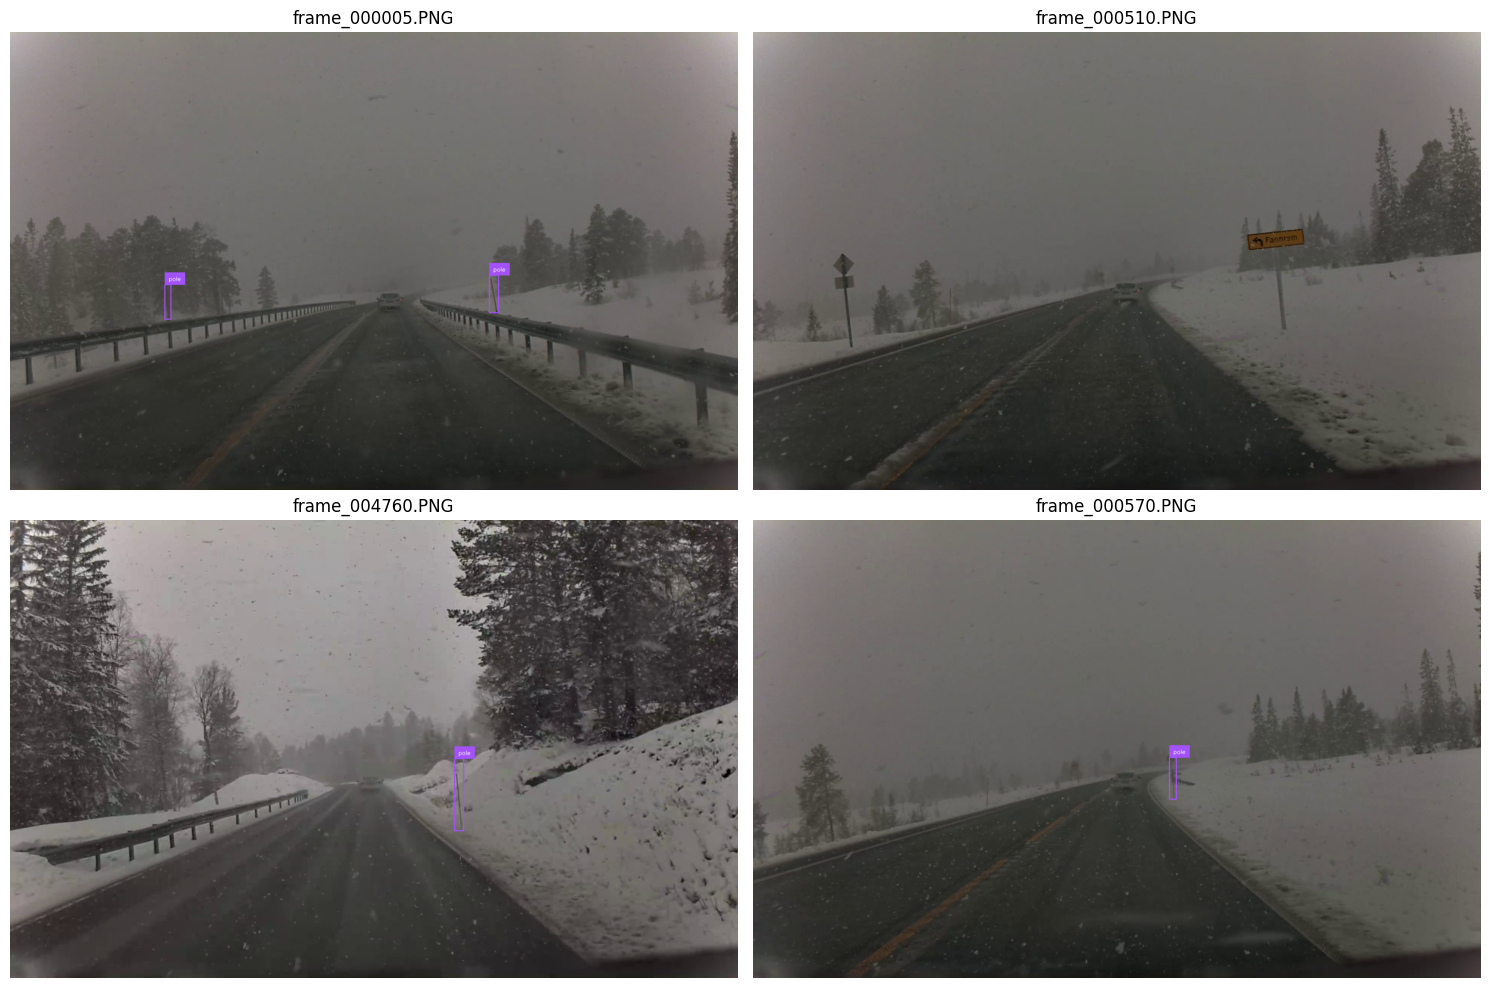

Processed 46 images
Results saved to: /home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results


In [41]:
import os
import cv2
import supervision as sv
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm  # For progress bar

# Load the trained model
model = YOLO("/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/runs_yolov12/runs/detect/train3/weights/best.pt")

# Find test images with case-insensitive extension matching
test_image_dir = f"{dataset_path}/images/test"
test_images = []
for img in os.listdir(test_image_dir):
    if img.upper().endswith('.PNG') or img.lower().endswith(('.png', '.jpg', '.jpeg')):
        test_images.append(os.path.join(test_image_dir, img))

# Create output directory for saving results
output_dir = "/home/omtalmo/Olaf_TTK4265/TDT4265-Snow-pole-detection/results"
os.makedirs(output_dir, exist_ok=True)

# Create annotators for visualization
bounding_box_annotator = sv.BoundingBoxAnnotator()
label_annotator = sv.LabelAnnotator()

# Process all test images
print(f"Processing {len(test_images)} test images...")
for image_path in tqdm(test_images):
    # Load and process the image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Warning: Could not load {image_path}")
        continue
    
    # Make predictions
    results = model(image)[0]
    detections = sv.Detections.from_ultralytics(results).with_nms()
    
    # Apply annotations
    annotated_image = bounding_box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)
    
    # Save the image result
    image_filename = Path(image_path).name
    output_path = os.path.join(output_dir, f"detection_{image_filename}")
    cv2.imwrite(output_path, annotated_image)

print(f"All results saved to {output_dir}")

# Optionally display a montage of some results (first 4 images)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, image_path in enumerate(test_images[:4]):
    if i >= 4:  # Limit to first 4 images
        break
        
    # Load the saved result
    image_filename = Path(image_path).name
    result_path = os.path.join(output_dir, f"detection_{image_filename}")
    
    if os.path.exists(result_path):
        result_img = cv2.imread(result_path)
        result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(result_img_rgb)
        axes[i].set_title(f"{image_filename}")
        axes[i].axis('off')
    
plt.tight_layout()
plt.show()

# Print summary 
print(f"Processed {len(test_images)} images")
print(f"Results saved to: {output_dir}")